In [23]:
import numpy as np
from scipy.sparse.linalg import expm, expm_multiply
from scipy.linalg import ishermitian
import matplotlib.pyplot as plt

from pyqsp.angle_sequence import QuantumSignalProcessingPhases
from pyqsp.poly import StringPolynomial
import pyqsp
from qiskit import QuantumCircuit
from utils import *

In [132]:
N = 64
qubits = N + N

In [133]:
x_vals = np.linspace(-1, 1, N)

In [163]:
psi_0 = np.zeros(qubits)
psi_0[:N] = np.cos(np.pi * x_vals)

In [184]:
# B = np.zeros(N,N-1)
# for i in range(N-1):
#     B[i,i] = 1
#     B[i+1,i] = -1

B = np.zeros((N,N))
for i in range(N):
    B[i,i] = 1
    B[(i+1) % N,i] = -1



In [185]:

H = np.block([[np.zeros((N,N)), np.conj(B)],[B.T, np.zeros((N,N))]])

In [186]:
T = 0.5
num_times = 64
psi = expm_multiply(-1j * H * N, psi_0, start=0, stop=T, num=num_times)

In [187]:
dist = np.abs(psi[:,:N]) ** 2

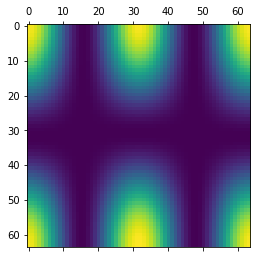

In [188]:
plt.matshow(dist)
plt.show()

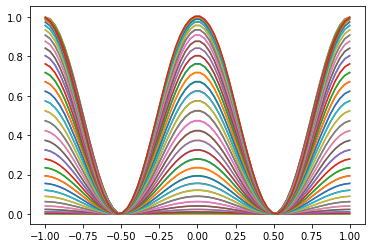

In [189]:
for i in range(num_times):
    plt.plot(x_vals, dist[i], label="i")

plt.show()

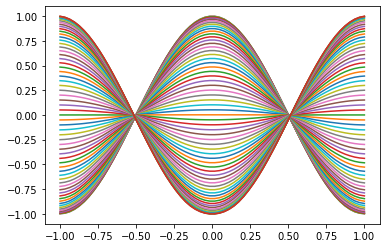

In [190]:
for i in range(num_times):
    plt.plot(x_vals, psi[i,:N].real, label="i")

plt.show()